# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Perkenalan Dataset
Nama Dataset: Superstore Sales Dataset

Sumber Dataset: Public Repository (Kaggle )

Format Awal: Spreadsheet/Excel (datasuperstore.xlsx)

📝 Deskripsi Dataset
Dataset ini berisi data historis transaksi penjualan dari sebuah perusahaan ritel skala besar (Superstore). Data ini mencakup seluruh siklus transaksi operasional retail, mulai dari informasi pengiriman (ship_mode), profil pelanggan (segment, city, state), pengelompokan produk (category, subcategory), hingga performa finansial dari setiap transaksi seperti total penjualan (sales), jumlah barang (quantity), potongan harga (discount), dan laba bersih (profit).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [24]:
# 1. Load dataset (pastikan file csv sudah kamu upload ke runtime Colab)
df_raw = pd.read_excel('/content/datasuperstore.xlsx')

df_raw.head()

,order_id,customer_id,postal_code,product_id,sales,quantity,discount,profit,category,subcategory,product_name,order_date,ship_date,ship_mode,customer_name,segment,country,city,state,region
0,CA-2019-152156,CG-12520,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136,Furniture,Bookcases,Bush Somerset Collection Bookcase,2019-11-08,2019-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
1,CA-2019-152156,CG-12520,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",2019-11-08,2019-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
2,CA-2019-138688,DV-13045,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,2019-06-12,2019-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West
3,US-2018-108966,SO-20335,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,2018-10-11,2018-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South
4,US-2018-108966,SO-20335,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,2018-10-11,2018-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_4684/3784904613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='target_visual', palette='Set2')
/tmp/ipykernel_4684/3784904613.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='target_visual', y='discount', palette='Set1')


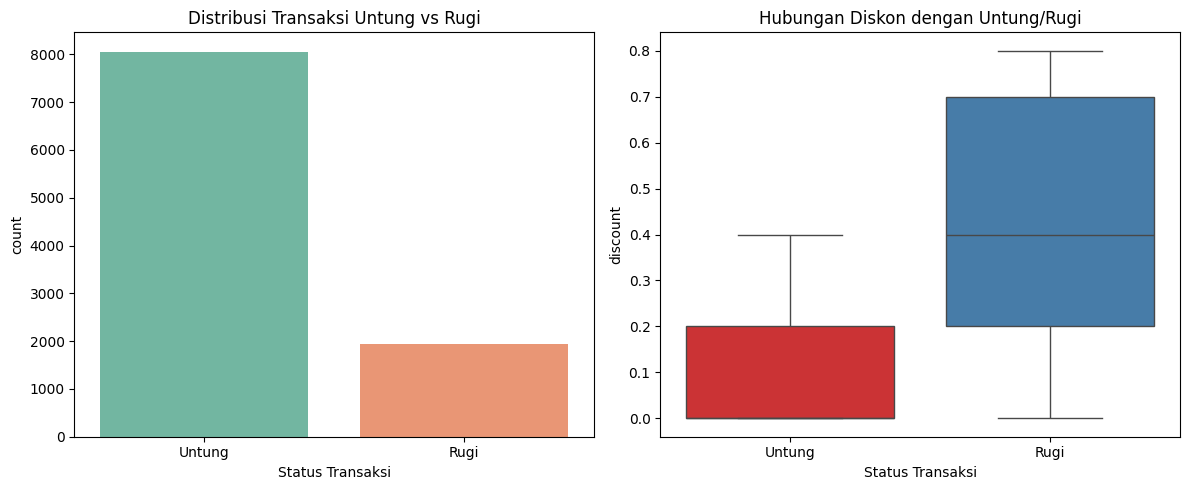

In [26]:
# Membuat kolom target sementara untuk visualisasi (Profit > 0 artinya Untung)
df_raw['target_visual'] = np.where(df_raw['profit'] > 0, 'Untung', 'Rugi')

plt.figure(figsize=(12, 5))

# Grafik 1: Distribusi Untung vs Rugi
plt.subplot(1, 2, 1)
sns.countplot(data=df_raw, x='target_visual', palette='Set2')
plt.title('Distribusi Transaksi Untung vs Rugi')
plt.xlabel('Status Transaksi')

# Grafik 2: Pengaruh Diskon terhadap Target
plt.subplot(1, 2, 2)
sns.boxplot(data=df_raw, x='target_visual', y='discount', palette='Set1')
plt.title('Hubungan Diskon dengan Untung/Rugi')
plt.xlabel('Status Transaksi')

plt.tight_layout()
plt.show()

Berdasarkan grafik Boxplot di atas, terlihat jelas bahwa transaksi yang Rugi (0) memiliki rata-rata diskon yang jauh lebih tinggi (bahkan banyak yang di atas 40%-80%) dibandingkan transaksi yang Untung (1) yang rata-rata diskonnya berada di dekat angka 0%. Ini membuktikan fitur diskon sangat krusial untuk model

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 1. Menghapus atau Menangani Data Kosong
print("--- Pengecekan Missing Values ---")
print(df_raw.isnull().sum())


# 2. Menghapus Data Duplikat
print("--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df_raw.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")




# 3. Deteksi Outlier (Pencilan)
# ==========================================
print("--- Deteksi Outlier pada Kolom Numerik ---")
# Kita cek menggunakan statistik deskriptif
print(df_raw[['sales', 'quantity', 'discount', 'profit']].describe())

--- Pengecekan Missing Values ---
order_id         0
customer_id      0
postal_code      0
product_id       0
sales            0
quantity         0
discount         0
profit           0
category         0
subcategory      0
product_name     0
order_date       0
ship_date        0
ship_mode        0
customer_name    0
segment          0
country          0
city             0
state            0
region           0
target           0
dtype: int64
--- Pengecekan Data Duplikat ---
Jumlah data duplikat: 0
--- Deteksi Outlier pada Kolom Numerik ---
              sales     quantity     discount       profit
count   9993.000000  9993.000000  9993.000000  9993.000000
mean     229.852846     3.789753     0.156188    28.660971
std      623.276074     2.225149     0.206457   234.271476
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.731000
50%       54.480000     3.000000     0.200000     8.671000
75%      209.940000     5.000000     0.20

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Selalu buat salinan dari df_raw agar aman saat di-run ulang
df_preprocessing = df_raw.copy()

# 2. Membuat Kolom Target Utama (1 = Untung, 0 = Rugi)
df_preprocessing['target'] = (df_preprocessing['profit'] > 0).astype(int)

# 3. Ekstrak Fitur dari Tanggal
df_preprocessing['order_date'] = pd.to_datetime(df_preprocessing['order_date'])
df_preprocessing['order_month'] = df_preprocessing['order_date'].dt.month
df_preprocessing['order_year'] = df_preprocessing['order_date'].dt.year

# 4. Membuang kolom ID, Nama, tanggal asli, dan profit asli (agar tidak terjadi kebocoran data)
kolom_tidak_dipakai = [
    'order_id', 'customer_id', 'customer_name', 'product_id',
    'product_name', 'postal_code', 'profit', 'order_date', 'ship_date', 'target_visual'
]
df_clean = df_preprocessing.drop(columns=kolom_tidak_dipakai, errors='ignore')

# 5. Mengubah data teks kategorikal menjadi angka
kolom_kategorikal = ['category', 'subcategory', 'ship_mode', 'segment', 'country', 'city', 'state', 'region']
le = LabelEncoder()
for col in kolom_kategorikal:
    df_clean[col] = le.fit_transform(df_clean[col])

# 6. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# 7. Membagi data menjadi 80% Train dan 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("🎉 Pra-pemrosesan selesai tanpa eror!")
print(f"Data Training: {X_train.shape[0]} baris | Data Testing: {X_test.shape[0]} baris")

🎉 Pra-pemrosesan selesai tanpa eror!
Data Training: 7994 baris | Data Testing: 1999 baris


In [28]:
# Menyimpan data yang sudah bersih menjadi file CSV baru
nama_file_output = 'superstore_preprocessing.csv'
df_clean.to_csv(nama_file_output, index=False)

print(f"🎉 Sukses! File '{nama_file_output}' telah berhasil dibuat.")
print("Silakan cek folder di kiri Colab, download file tersebut, dan masukkan ke repositori proyekmu!")

🎉 Sukses! File 'superstore_preprocessing.csv' telah berhasil dibuat.
Silakan cek folder di kiri Colab, download file tersebut, dan masukkan ke repositori proyekmu!


In [30]:
%%writefile automate_MuhammadHuseinAbdullahMahfud.py
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def jalankan_otomatisasi(input_path, output_path):
    print(f"🔄 Memulai otomatisasi pra-pemrosesan...")
    print(f"📂 Membaca data mentah dari: {input_path}")

    # 1. Validasi cek apakah file mentah ada
    if not os.path.exists(input_path):
        print(f" Eror: File mentah di '{input_path}' tidak ditemukan!")
        return

    # 2. Membaca data asli
    df_raw = pd.read_csv(input_path)
    df_preprocessing = df_raw.copy()

    # 3. Membuat Kolom Target Utama (1 = Untung, 0 = Rugi)
    df_preprocessing['target'] = (df_preprocessing['profit'] > 0).astype(int)

    # 4. Ekstrak Fitur dari Tanggal
    df_preprocessing['order_date'] = pd.to_datetime(df_preprocessing['order_date'])
    df_preprocessing['order_month'] = df_preprocessing['order_date'].dt.month
    df_preprocessing['order_year'] = df_preprocessing['order_date'].dt.year

    # 5. Membuang kolom identitas dan kolom target asli agar tidak bocor
    kolom_tidak_dipakai = [
        'order_id', 'customer_id', 'customer_name', 'product_id',
        'product_name', 'postal_code', 'profit', 'order_date', 'ship_date', 'target_visual'
    ]
    df_clean = df_preprocessing.drop(columns=kolom_tidak_dipakai, errors='ignore')

    # 6. Mengubah data teks kategorikal menjadi angka (Encoding)
    kolom_kategorikal = ['category', 'subcategory', 'ship_mode', 'segment', 'country', 'city', 'state', 'region']
    le = LabelEncoder()
    for col in kolom_kategorikal:
        df_clean[col] = le.fit_transform(df_clean[col])

    # 7. Membuat folder output secara otomatis jika belum ada
    folder_output = os.path.dirname(output_path)
    if folder_output and not os.path.exists(folder_output):
        os.makedirs(folder_output, exist_ok=True)

    # 8. Menyimpan hasil ke CSV baru
    df_clean.to_csv(output_path, index=False)
    print(f"🎉 Sukses! Data bersih berhasil disimpan di: {output_path}")
    print(f"📐 Ukuran data akhir: {df_clean.shape}")

if __name__ == "__main__":
    # Konfigurasi jalur file disesuaikan dengan struktur standar repositori kamu
    # Skrip ini dirancang untuk dijalankan dari root folder proyek
    PATH_INPUT = "namadataset_raw/superstore.csv"
    PATH_OUTPUT = "preprocessing/namadataset_preprocessing/superstore_preprocessing.csv"

    jalankan_otomatisasi(PATH_INPUT, PATH_OUTPUT)

Writing automate_MuhammadHuseinAbdullahMahfud.py
